# Monte Carlo Tree Search (MCTS) with UCT
This notebook introduces the core ideas behind Monte Carlo Tree Search (MCTS)
using a minimal working example based on UCT (Upper Confidence Bound applied to Trees).

You will implement:
- UCT-based **Selection**
- Node **Expansion**
- **Rollout** simulation
- **Backpropagation** of returns
- Tracking visit counts and Q-values
- Updating action preferences at the root node

We will follow the four classical MCTS phases.


In [1]:
import math
import random

# Good research should be reproducible - lets get a random seed
random.seed(42)


In [2]:
# Consider the following initial problem situation
Q = {("s0", "a1"): 0.55,
     ("s0", "a2"): 0.40}

N = {"s0": 20}   #Total number of visits for the state
Nsa = {("s0", "a1"): 12,
       ("s0", "a2"): 8}  # visit counts per action in the state

c = math.sqrt(2)   # some exploration constant


In [3]:
def uct(s, a):
    """Will help compute the UCT score for action a in state s."""
    return Q[(s, a)] + c * math.sqrt(math.log(N[s]) / Nsa[(s, a)])


### Task 1:
write code to print the UCT score for both a1 and a2 at s0. Further, print which action, UCT  selects


In [4]:
# Task 1: UCT scores at the root and the action UCT selects
uct_a1 = uct("s0", "a1")
uct_a2 = uct("s0", "a2")
print(f"UCT(s0, a1) = {uct_a1:.4f}")
print(f"UCT(s0, a2) = {uct_a2:.4f}")

selected = max(["a1", "a2"], key=lambda a: uct("s0", a))
print(f"UCT selects: {selected}")

UCT(s0, a1) = 1.2566
UCT(s0, a2) = 1.2654
UCT selects: a2


As discussed in class, each iteration of MCTS consists of four key phases:

 * Selection: Starting at the root, select child nodes  until a leaf is reached using a balance between exploration and exploitation.
 * Expansion: Add one or more new child nodes (previously unvisited states).
 * Rollout Perform a random or heuristic-guided simulation from the new node to a terminal state to estimate its value.
* Backpropagation Update value estimates and visit counts along the path back to the root.






In [5]:
def run_iteration(iteration_num=None):
    #Run one iteration of MCTS with detailed logging.

    if iteration_num is not None:
        print(f"\n{'=' * 60}")
        print(f"ITERATION {iteration_num}")
        print(f"{'=' * 60}")

    # (1) --- Selection ---
    if iteration_num is not None:
        print("\n(1) SELECTION:")
        print(f"  Current Q-values: Q(s0,a1)={Q[('s0','a1')]:.4f}, Q(s0,a2)={Q[('s0','a2')]:.4f}")
        print(f"  Current visit counts: N(s0,a1)={Nsa[('s0','a1')]}, N(s0,a2)={Nsa[('s0','a2')]}")
        print(f"  UCT(s0,a1)={uct('s0','a1'):.4f}, UCT(s0,a2)={uct('s0','a2'):.4f}")

    a = max(["a1", "a2"], key=lambda x: uct("s0", x))

    if iteration_num is not None:
        print(f"  Selected action: {a}")

    # (2) --- Expansion ---
    if iteration_num is not None:
        print("\n(2) EXPANSION:")
        print(f"  Expanding from s0 via action {a} to create new child state s_new")

    s_new = "s_new"

    # (3) --- Rollout ---
    R = random.random()  # Return from simulation

    if iteration_num is not None:
        print("\n(3) ROLLOUT:")
        print(f"  Simulating from s_new to terminal state")
        print(f"  Return received: R = {R:.4f}")

    # (4) --- Backpropagation ---
    if iteration_num is not None:
        print("\n(4) BACKPROPAGATION:")
        print(f"  Before update: N(s0)={N['s0']}, N(s0,{a})={Nsa[('s0',a)]}, Q(s0,{a})={Q[('s0',a)]:.4f}")

    N["s0"] += 1
    Nsa[("s0", a)] += 1

    # Incremental mean update:
    Q[(s0 := "s0", a)] += (R - Q[(s0, a)]) / Nsa[(s0, a)]

    if iteration_num is not None:
        print(f"  After update:  N(s0)={N['s0']}, N(s0,{a})={Nsa[('s0',a)]}, Q(s0,{a})={Q[('s0',a)]:.4f}")

    return a, R



**Task 2:**  
Write code to run simulations, before running each iteration document what changes during:
- Selection  
- Expansion  
- Rollout  
- Backpropagation  


In [6]:
# Task 2: run 20 MCTS iterations.
# For every iteration, run_iteration(iteration_num=i) logs what changes in each phase:
#  (1) Selection:      UCT scores are recomputed from the current Q and visit counts,
#                      and the action with the higher UCT score is chosen.
#  (2) Expansion:      a new child node s_new is added under the selected action.
#  (3) Rollout:        a simulation from s_new returns a random return R.
#  (4) Backpropagation: N(s0) and N(s0, a) are incremented, and Q(s0, a) is moved
#                      toward R by the incremental-mean update Q += (R - Q) / N(s0, a).
history = []
for i in range(1, 21):
    a, R = run_iteration(iteration_num=i)
    history.append((i, a, R, Q[("s0", "a1")], Q[("s0", "a2")]))


ITERATION 1

(1) SELECTION:
  Current Q-values: Q(s0,a1)=0.5500, Q(s0,a2)=0.4000
  Current visit counts: N(s0,a1)=12, N(s0,a2)=8
  UCT(s0,a1)=1.2566, UCT(s0,a2)=1.2654
  Selected action: a2

(2) EXPANSION:
  Expanding from s0 via action a2 to create new child state s_new

(3) ROLLOUT:
  Simulating from s_new to terminal state
  Return received: R = 0.6394

(4) BACKPROPAGATION:
  Before update: N(s0)=20, N(s0,a2)=8, Q(s0,a2)=0.4000
  After update:  N(s0)=21, N(s0,a2)=9, Q(s0,a2)=0.4266

ITERATION 2

(1) SELECTION:
  Current Q-values: Q(s0,a1)=0.5500, Q(s0,a2)=0.4266
  Current visit counts: N(s0,a1)=12, N(s0,a2)=9
  UCT(s0,a1)=1.2623, UCT(s0,a2)=1.2491
  Selected action: a1

(2) EXPANSION:
  Expanding from s0 via action a1 to create new child state s_new

(3) ROLLOUT:
  Simulating from s_new to terminal state
  Return received: R = 0.0250

(4) BACKPROPAGATION:
  Before update: N(s0)=21, N(s0,a1)=12, Q(s0,a1)=0.5500
  After update:  N(s0)=22, N(s0,a1)=13, Q(s0,a1)=0.5096

ITERATION 3

(1

### Task 3:

Write code that will print:
Final Q values,

*   Final Q values
*   Final Visit Counts
*   Preferred at root, s0



In [7]:
# Task 3: final statistics after the 20 iterations
print("Final Q values:")
for (s, a), q in Q.items():
    print(f"  Q({s}, {a}) = {q:.4f}")

print("\nFinal visit counts:")
print(f"  N(s0) = {N['s0']}")
for (s, a), n in Nsa.items():
    print(f"  N({s}, {a}) = {n}")

preferred = max(["a1", "a2"], key=lambda a: Q[("s0", a)])
print(f"\nPreferred action at root s0 (highest Q): {preferred}")

Final Q values:
  Q(s0, a1) = 0.4693
  Q(s0, a2) = 0.3990

Final visit counts:
  N(s0) = 40
  N(s0, a1) = 23
  N(s0, a2) = 17

Preferred action at root s0 (highest Q): a1


### Task 4:
Interpret the results:
1. Which action does MCTS end up preferring?
2. Why did the preferred action change or stay the same over the 20 iterations?
3. How does UCT balance exploration and exploitation in your observed results?



### Task 4 — Answers

**1. Which action does MCTS end up preferring?**
MCTS ends up preferring **a1**: after the 20 iterations, Q(s0, a1) = 0.4693 > Q(s0, a2) = 0.3990, and a1 was also visited more often (N(s0, a1) = 23 vs N(s0, a2) = 17).

**2. Why did the preferred action change or stay the same over the 20 iterations?**
The preferred action **stayed the same** (a1 started with the higher value, 0.55 vs 0.40, and kept the higher value at the end). What did change is which action was *selected* on individual iterations: on the very first iteration UCT picked a2, because a2's smaller visit count (8 vs 12) gave it a larger exploration bonus that outweighed its lower Q. Since the rollout returns are uniform on [0, 1] for both actions, both Q estimates drifted toward ≈ 0.5, and a2's extra samples never revealed it to be better, so a1 remained the preferred action at the root.

**3. How does UCT balance exploration and exploitation in your observed results?**
UCT adds the bonus c·sqrt(ln N(s0) / N(s0, a)) to each Q value. Early on, the less-visited a2 got a larger bonus and was selected even though its Q was lower — that is exploration. Each time an action was selected, its visit count grew and its bonus shrank, letting the other action's UCT score catch up; this is why the selections alternate between a1 and a2 in the iteration logs instead of locking onto one action. As counts grew, the bonuses became more similar and the Q terms (exploitation) increasingly drove selection, which is why a1 — the action with the higher estimated value — accumulated more visits (23 vs 17) by the end.

## Optional Challenge:
Extend this notebook by implementing:

1. A real tree structure with:
   - multiple layers,
   - children stored in a dictionary: `children[s] = [list_of_actions]`.

2. A real rollout policy (random or epsilon-greedy).

3. Backpropagation that updates *all* ancestors, not only s0.

4. Visualization of visit counts as a bar chart.


## Optional Challenge — Implementation

Below, the single-node example above is extended into a **full MCTS** with:

1. a real tree with multiple layers, children stored as `children[s] = [list_of_actions]`;
2. a real rollout policy (uniform random over the available actions);
3. backpropagation that updates **all** ancestors on the path, not only s0;
4. a bar-chart visualization of the visit counts.

The environment is a small two-level tree rooted at s0. Terminal states pay a
uniform random reward in the ranges below, so the optimal path is
s0 → a1 → s1 → a3 → t1 (mean reward 0.85).

In [8]:
# (1) A real tree structure with multiple layers
random.seed(7)  # separate seed so the results above are unaffected

children = {"s0": ["a1", "a2"],      # children[s] = list of available actions
            "s1": ["a3", "a4"],
            "s2": ["a5", "a6"]}
T = {("s0", "a1"): "s1", ("s0", "a2"): "s2",
     ("s1", "a3"): "t1", ("s1", "a4"): "t2",
     ("s2", "a5"): "t3", ("s2", "a6"): "t4"}

# Terminal states pay a uniform random reward in these ranges
reward_range = {"t1": (0.7, 1.0),   # best
                "t2": (0.2, 0.5),
                "t3": (0.4, 0.7),
                "t4": (0.0, 0.3)}   # worst

def is_terminal(s):
    return s not in children

# Tree statistics (kept separate from the single-node example above)
tQ, tN, tNsa = {}, {}, {}
expanded = {"s0"}   # states whose statistics are stored in the tree

def tree_uct(s, a):
    if tNsa.get((s, a), 0) == 0:
        return float("inf")   # every untried action is visited once first
    return tQ[(s, a)] + c * math.sqrt(math.log(tN[s]) / tNsa[(s, a)])

# (2) A real rollout policy: uniform random until a terminal state
def rollout(s):
    while not is_terminal(s):
        s = T[(s, random.choice(children[s]))]
    return random.uniform(*reward_range[s])

def mcts_iteration():
    # Selection: descend with UCT while inside the expanded part of the tree
    path, s = [], "s0"
    while not is_terminal(s) and s in expanded:
        a = max(children[s], key=lambda x: tree_uct(s, x))
        path.append((s, a))
        s = T[(s, a)]
        if tNsa.get(path[-1], 0) == 0:
            break   # this edge is new -> stop selection and expand below
    # Expansion: add the newly reached (non-terminal) state to the tree
    if not is_terminal(s):
        expanded.add(s)
    # Rollout: simulate from the new state to a terminal state
    R = rollout(s)
    # (3) Backpropagation: update ALL ancestors on the path, not only s0
    for (ps, pa) in path:
        tN[ps] = tN.get(ps, 0) + 1
        tNsa[(ps, pa)] = tNsa.get((ps, pa), 0) + 1
        q = tQ.get((ps, pa), 0.0)
        tQ[(ps, pa)] = q + (R - q) / tNsa[(ps, pa)]
    return path, R

for _ in range(200):
    mcts_iteration()

print("Edge statistics after 200 iterations:")
for (s, a) in sorted(tNsa):
    print(f"  Q({s}, {a}) = {tQ[(s, a)]:.4f}   N({s}, {a}) = {tNsa[(s, a)]}")
print(f"\nState visit counts: {tN}")

s, greedy_path = "s0", []
while not is_terminal(s):
    a = max(children[s], key=lambda x: tQ.get((s, x), 0.0))
    greedy_path.append((s, a))
    s = T[(s, a)]
print(f"Greedy (most valuable) path from the root: {greedy_path} -> {s}")

Edge statistics after 200 iterations:
  Q(s0, a1) = 0.7960   N(s0, a1) = 174
  Q(s0, a2) = 0.3927   N(s0, a2) = 26
  Q(s1, a3) = 0.8490   N(s1, a3) = 157
  Q(s1, a4) = 0.2961   N(s1, a4) = 16
  Q(s2, a5) = 0.5213   N(s2, a5) = 18
  Q(s2, a6) = 0.0903   N(s2, a6) = 7

State visit counts: {'s0': 200, 's1': 173, 's2': 25}
Greedy (most valuable) path from the root: [('s0', 'a1'), ('s1', 'a3')] -> t1


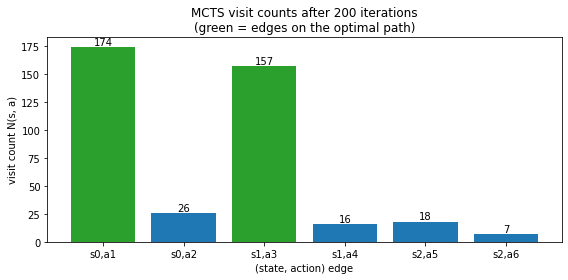

In [9]:
# (4) Visualization of visit counts as a bar chart
import matplotlib.pyplot as plt

labels = [f"{s},{a}" for (s, a) in sorted(tNsa)]
counts = [tNsa[k] for k in sorted(tNsa)]
colors = ["tab:green" if (k in [("s0","a1"), ("s1","a3")]) else "tab:blue"
          for k in sorted(tNsa)]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, counts, color=colors)
ax.bar_label(bars)
ax.set_xlabel("(state, action) edge")
ax.set_ylabel("visit count N(s, a)")
ax.set_title("MCTS visit counts after 200 iterations\n(green = edges on the optimal path)")
plt.tight_layout()
plt.savefig("mcts_visit_counts.png", dpi=150, bbox_inches="tight")
plt.show()

### Optional Challenge — Observations

MCTS correctly identifies the optimal path **s0 → a1 → s1 → a3 → t1**: the value
estimates converge near the true means (Q(s1, a3) ≈ 0.85, the mean of the best
terminal reward range), and the visit counts concentrate on the optimal edges
(N(s0, a1) = 174 vs N(s0, a2) = 26, and N(s1, a3) = 157 vs N(s1, a4) = 16).
Because untried actions get an infinite UCT score, every edge is explored at
least once, and the shrinking exploration bonus then lets exploitation focus
the search on the most promising branch — the same exploration/exploitation
behaviour observed in Task 4, now over a multi-level tree.